# IBM HR Employee Attrition — Exploratory Data Analysis

**Group 6 | IE University MLOps Final Project**  
**Team:** Francisco Concha, Aylin Yasgul, Martin Schneider, Bader Al Eisa, Quifeng Cai

**Business question:** Which employee characteristics are most predictive of voluntary resignation, and can we build a reliable early-warning system for HR teams?

This notebook covers:
1. Data quality check
2. Target variable analysis and class imbalance
3. Naïve baseline benchmark
4. Key categorical and numeric feature analysis
5. Tenure stage analysis
6. Correlation with attrition
7. Fairness audit on protected attributes (Age, Gender, MaritalStatus)
8. Key findings summary

---

## 0. Setup

In [ ]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import f1_score, recall_score, precision_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PLOT_DIR = Path('../data/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
df = pd.read_csv('../data/IBM_emp_attrition.csv', sep=';')
print(f'Dataset shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
df.head(3)

Dataset shape: (1470, 35)
Columns (35): ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


## 2. Data Quality Check

In [3]:
print('=== Missing Values ===')
print(f'Total missing: {df.isnull().sum().sum()} — no imputation needed')

print('\n=== Duplicate Rows ===')
print(f'Total duplicates: {df.duplicated().sum()}')

print('\n=== Constant Columns (zero variance — will be dropped in Stage 02) ===')
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
for c in constant_cols:
    print(f'  {c}: always = {df[c].unique()[0]}')

print('\n=== ID Column (no predictive value — will be dropped in Stage 02) ===')
print(f'  EmployeeNumber: {df["EmployeeNumber"].nunique()} unique values (one per row)')

=== Missing Values ===
Total missing: 0 — no imputation needed

=== Duplicate Rows ===
Total duplicates: 0

=== Constant Columns (zero variance — will be dropped in Stage 02) ===
  EmployeeCount: always = 1
  Over18: always = Y
  StandardHours: always = 80

=== ID Column (no predictive value — will be dropped in Stage 02) ===
  EmployeeNumber: 1470 unique values (one per row)


**Findings:**
- No missing values, no duplicates — no data repair needed
- `EmployeeCount`, `StandardHours`, `Over18` are constant — zero predictive value
- `EmployeeNumber` is an administrative ID — not a real feature

All four will be dropped in Stage 02.

## 3. Target Variable: Attrition & Class Imbalance

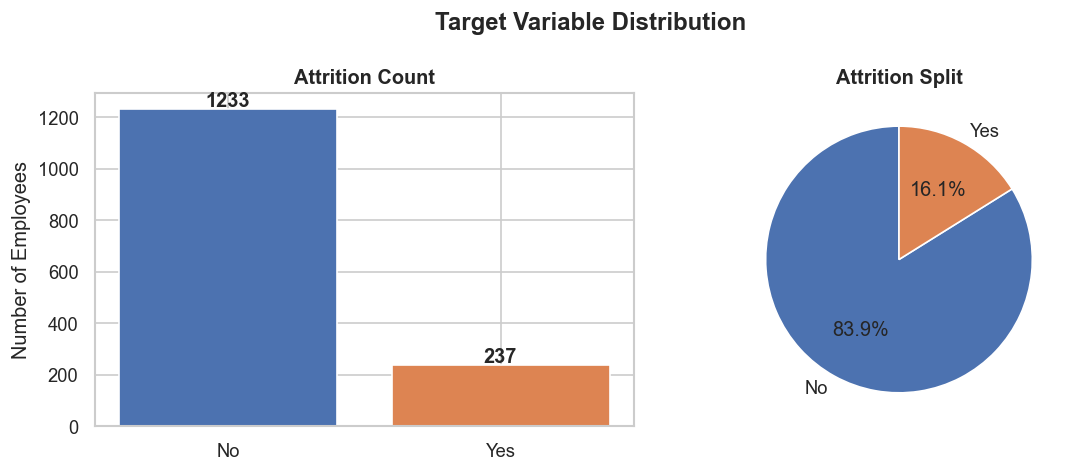

No  (stayed): 1233  (83.9%)
Yes (left):   237  (16.1%)

IMPLICATION: The dataset is imbalanced. A model that always predicts "No"
achieves 83.9% accuracy while catching zero leavers — useless for HR.
Primary metric must be F1-score on the attrition class, not accuracy.


In [4]:
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(attrition_counts.index, attrition_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Attrition Count', fontweight='bold')
axes[0].set_ylabel('Number of Employees')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(attrition_counts.values, labels=attrition_counts.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Attrition Split', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '01_attrition_distribution.png', bbox_inches='tight')
plt.show()

print(f'No  (stayed): {attrition_counts["No"]}  ({attrition_pct["No"]:.1f}%)')
print(f'Yes (left):   {attrition_counts["Yes"]}  ({attrition_pct["Yes"]:.1f}%)')
print()
print('IMPLICATION: The dataset is imbalanced. A model that always predicts "No"')
print('achieves 83.9% accuracy while catching zero leavers — useless for HR.')
print('Primary metric must be F1-score on the attrition class, not accuracy.')

## 4. Naïve Baseline: Always Predict "No Attrition"

Per the proposal, this is our first baseline — it establishes the floor every model must beat.

In [5]:
y_true = (df['Attrition'] == 'Yes').astype(int)
y_naive = np.zeros(len(y_true), dtype=int)  # always predict "No"

print('=== Naïve Baseline: Always Predict No Attrition ===')
print(f'  Accuracy : {(y_naive == y_true).mean()*100:.1f}%  <- looks good but is misleading')
print(f'  F1-Score : {f1_score(y_true, y_naive, zero_division=0):.3f}  <- completely useless')
print(f'  Recall   : {recall_score(y_true, y_naive, zero_division=0):.3f}  <- catches zero leavers')
print(f'  Precision: {precision_score(y_true, y_naive, zero_division=0):.3f}')
print()
print('This is the floor. Per the proposal:')
print('  Usefulness threshold : F1 >= 0.50')
print('  Target               : F1 >= 0.75 and ROC-AUC >= 0.80')

=== Naïve Baseline: Always Predict No Attrition ===
  Accuracy : 83.9%  <- looks good but is misleading
  F1-Score : 0.000  <- completely useless
  Recall   : 0.000  <- catches zero leavers
  Precision: 0.000

This is the floor. Per the proposal:
  Usefulness threshold : F1 >= 0.50
  Target               : F1 >= 0.75 and ROC-AUC >= 0.80


## 5. Attrition by Key Categorical Features

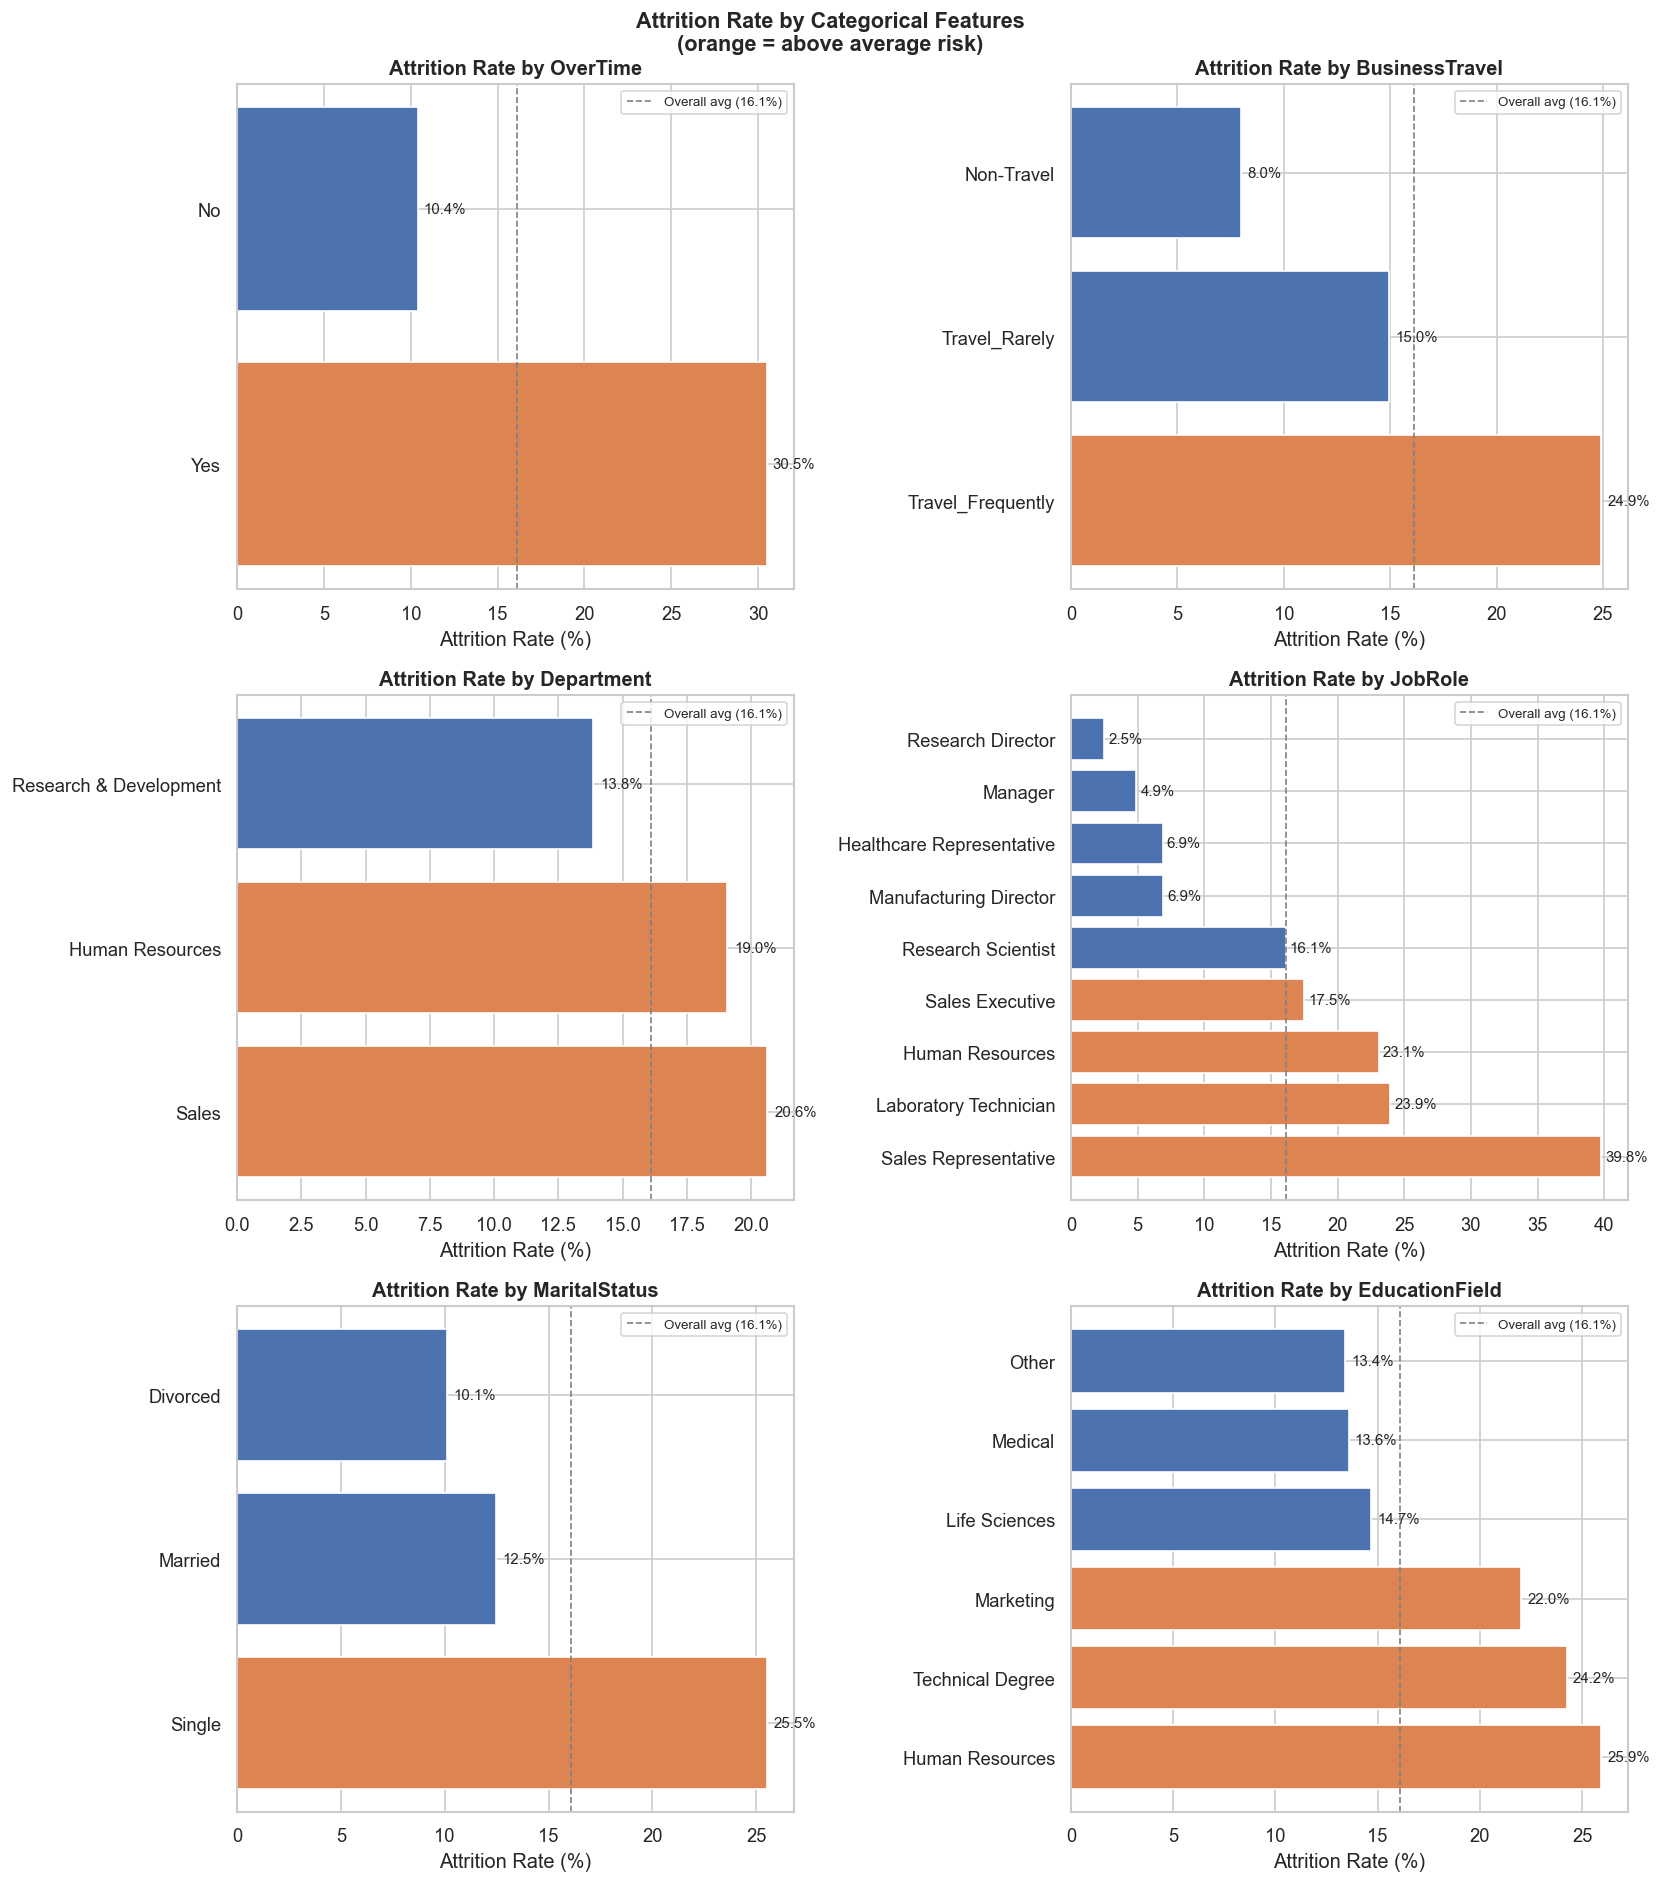

In [6]:
key_cats = ['OverTime', 'BusinessTravel', 'Department',
            'JobRole', 'MaritalStatus', 'EducationField']

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    rate = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)
    colors = ['#DD8452' if v > 16.1 else '#4C72B0' for v in rate.values]
    bars = axes[i].barh(rate.index, rate.values, color=colors, edgecolor='white')
    axes[i].axvline(x=16.1, color='gray', linestyle='--',
                    linewidth=1, label='Overall avg (16.1%)')
    axes[i].set_title(f'Attrition Rate by {col}', fontweight='bold')
    axes[i].set_xlabel('Attrition Rate (%)')
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, rate.values):
        axes[i].text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                     f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Attrition Rate by Categorical Features\n(orange = above average risk)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '02_categorical_attrition.png', bbox_inches='tight')
plt.show()

### Key Attrition Insights

* **OverTime:** Employees working overtime show much higher attrition, making overtime one of the strongest turnover risk signals.
* **Business Travel:** Frequent travelers have above-average attrition, suggesting travel burden may contribute to employee exits.
* **Department / Job Role:** Attrition is concentrated in sales-related roles, especially Sales Representatives, while senior roles such as Managers and Research Directors are far more stable.
* **Marital Status:** Single employees are significantly more likely to leave than married or divorced employees.
* **Education Field:** Employees from Human Resources, Technical Degree, and Marketing backgrounds show above-average attrition.

**Takeaway:** The company’s main retention challenge is concentrated in employees with overtime, frequent travel, sales-related roles, and single status, so retention actions should focus on these high-risk groups.


## 6. OverTime Deep Dive

OverTime is the strongest single categorical signal in the dataset.

In [7]:
ot_yes = (df[df['OverTime'] == 'Yes']['Attrition'] == 'Yes').mean() * 100
ot_no  = (df[df['OverTime'] == 'No']['Attrition']  == 'Yes').mean() * 100

print(f'Attrition rate — OverTime=Yes: {ot_yes:.1f}%')
print(f'Attrition rate — OverTime=No:  {ot_no:.1f}%')
print(f'Risk multiplier: {ot_yes/ot_no:.1f}x higher when working overtime')
print()
print('Business insight: employees working overtime AND earning below average')
print('are the highest-priority group for HR intervention.')

Attrition rate — OverTime=Yes: 30.5%
Attrition rate — OverTime=No:  10.4%
Risk multiplier: 2.9x higher when working overtime

Business insight: employees working overtime AND earning below average
are the highest-priority group for HR intervention.


## 7. Attrition by Key Numeric Features

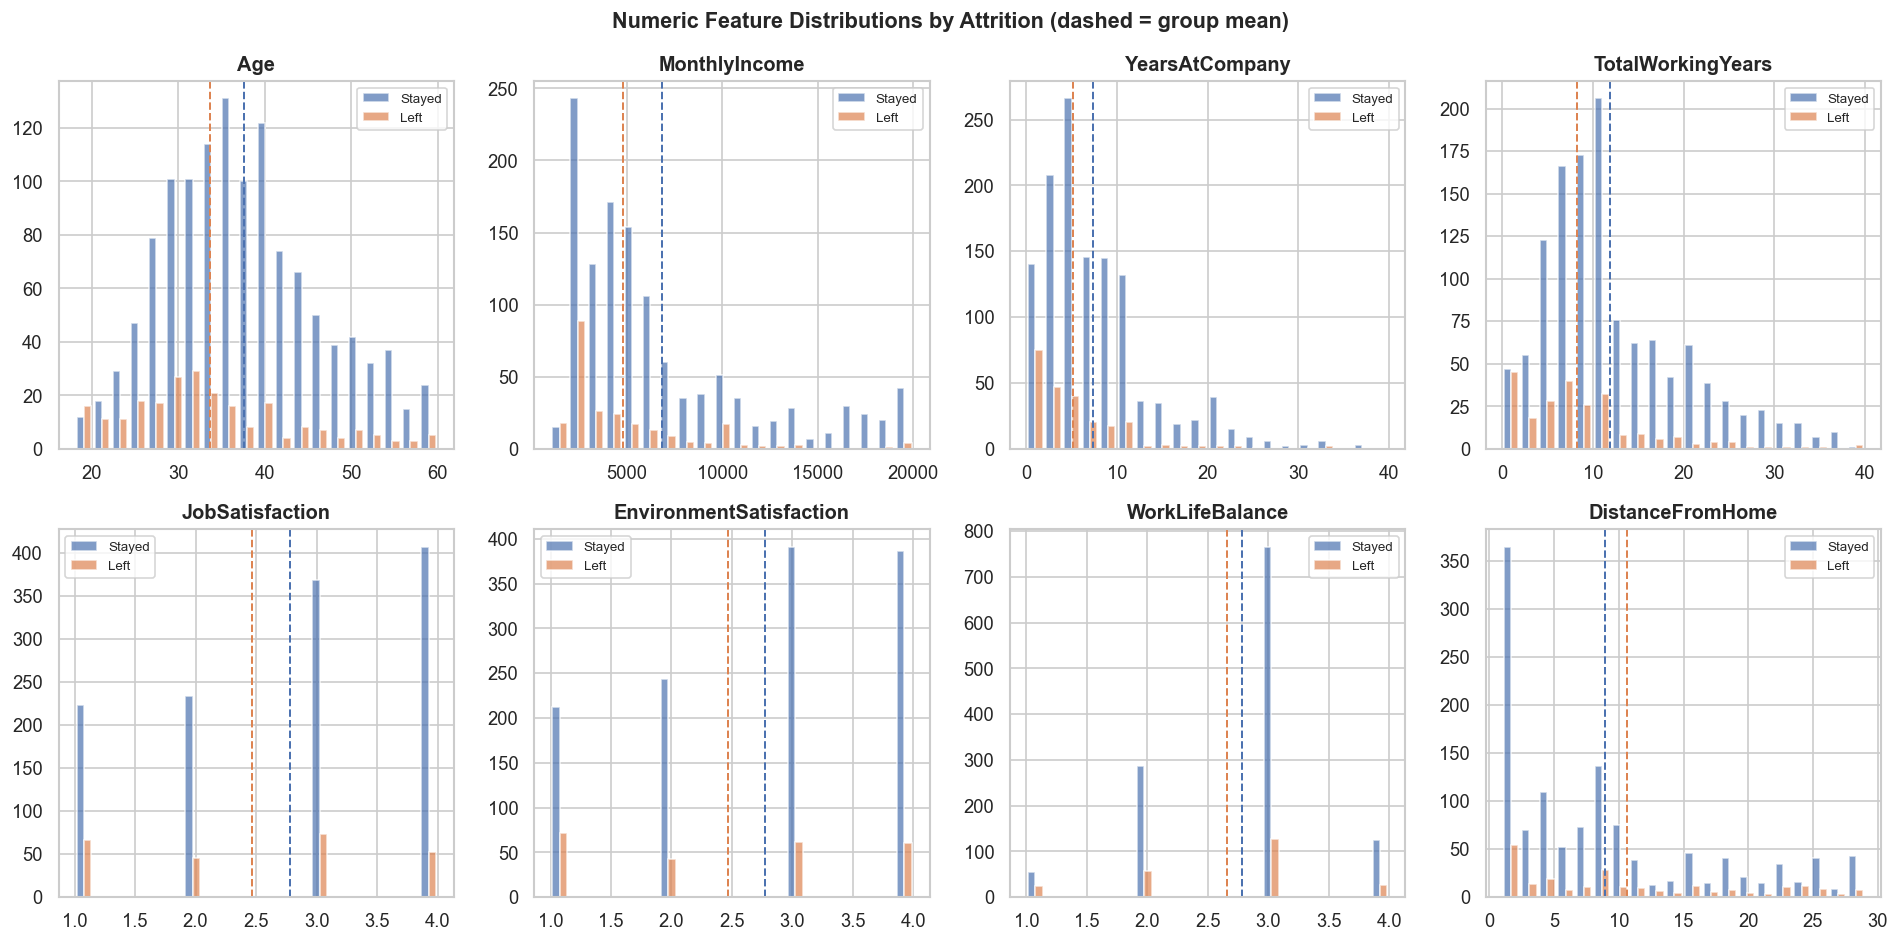

Feature                         Left (mean)  Stayed (mean)
----------------------------------------------------------
Age                                    33.6           37.6
MonthlyIncome                        4787.1         6832.7
YearsAtCompany                          5.1            7.4
TotalWorkingYears                       8.2           11.9
JobSatisfaction                         2.5            2.8
EnvironmentSatisfaction                 2.5            2.8
WorkLifeBalance                         2.7            2.8
DistanceFromHome                       10.6            8.9


In [8]:
key_nums = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears',
            'JobSatisfaction', 'EnvironmentSatisfaction',
            'WorkLifeBalance', 'DistanceFromHome']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_nums):
    yes = df[df['Attrition'] == 'Yes'][col]
    no  = df[df['Attrition'] == 'No'][col]
    axes[i].hist([no, yes], bins=20,
                 label=['Stayed', 'Left'],
                 color=['#4C72B0', '#DD8452'],
                 alpha=0.7, edgecolor='white')
    axes[i].axvline(yes.mean(), color='#DD8452', linestyle='--', linewidth=1.2)
    axes[i].axvline(no.mean(),  color='#4C72B0',  linestyle='--', linewidth=1.2)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Numeric Feature Distributions by Attrition (dashed = group mean)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '03_numeric_distributions.png', bbox_inches='tight')
plt.show()

print(f'{"Feature":<30} {"Left (mean)":>12} {"Stayed (mean)":>14}')
print('-' * 58)
for col in key_nums:
    m_yes = df[df['Attrition'] == 'Yes'][col].mean()
    m_no  = df[df['Attrition'] == 'No'][col].mean()
    print(f'{col:<30} {m_yes:>12.1f} {m_no:>14.1f}')

## 8. Tenure Stage Analysis

Validates the `TenureBucket` engineered feature proposed in the proposal (0–2, 3–7, 8+ years).

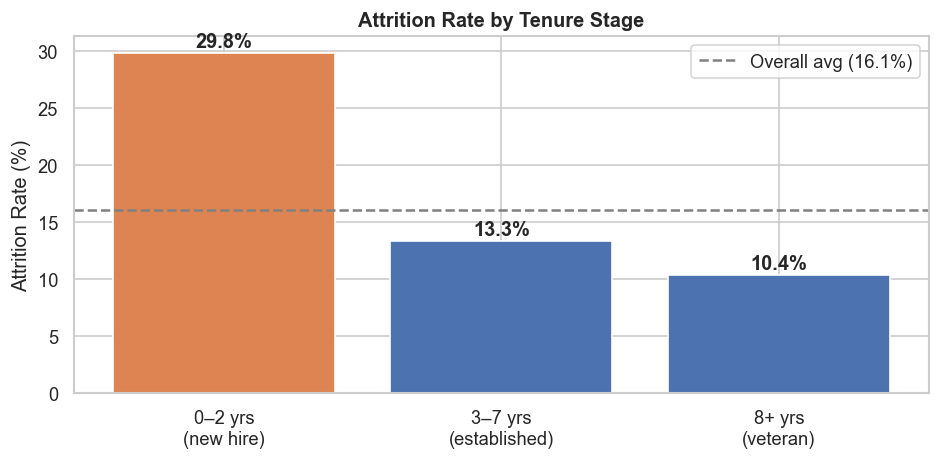

0–2 yrs (new hire)       : 29.8% attrition  (n=342)
3–7 yrs (established)    : 13.3% attrition  (n=600)
8+ yrs (veteran)         : 10.4% attrition  (n=528)

Finding: New hires (0-2 yrs) have nearly 3x the attrition rate of veterans.
TenureBucket captures the well-known new-hire vulnerability effect — justified.


In [9]:
df['TenureBucket'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 2, 7, 100],
    labels=['0–2 yrs\n(new hire)', '3–7 yrs\n(established)', '8+ yrs\n(veteran)']
)

tenure_rate = df.groupby('TenureBucket', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
tenure_count = df.groupby('TenureBucket', observed=True).size()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#DD8452' if v > 16.1 else '#4C72B0' for v in tenure_rate.values]
bars = ax.bar(tenure_rate.index.astype(str), tenure_rate.values,
              color=colors, edgecolor='white')
ax.axhline(y=16.1, color='gray', linestyle='--', label='Overall avg (16.1%)')
ax.set_title('Attrition Rate by Tenure Stage', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.legend()
for bar, (label, val) in zip(bars, tenure_rate.items()):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '04_tenure_attrition.png', bbox_inches='tight')
plt.show()

for label in tenure_rate.index:
    print(f'{str(label).replace(chr(10)," "):<25}: {tenure_rate[label]:.1f}% attrition  (n={tenure_count[label]})')
print()
print('Finding: New hires (0-2 yrs) have nearly 3x the attrition rate of veterans.')
print('TenureBucket captures the well-known new-hire vulnerability effect — justified.')

## 9. Correlation with Attrition

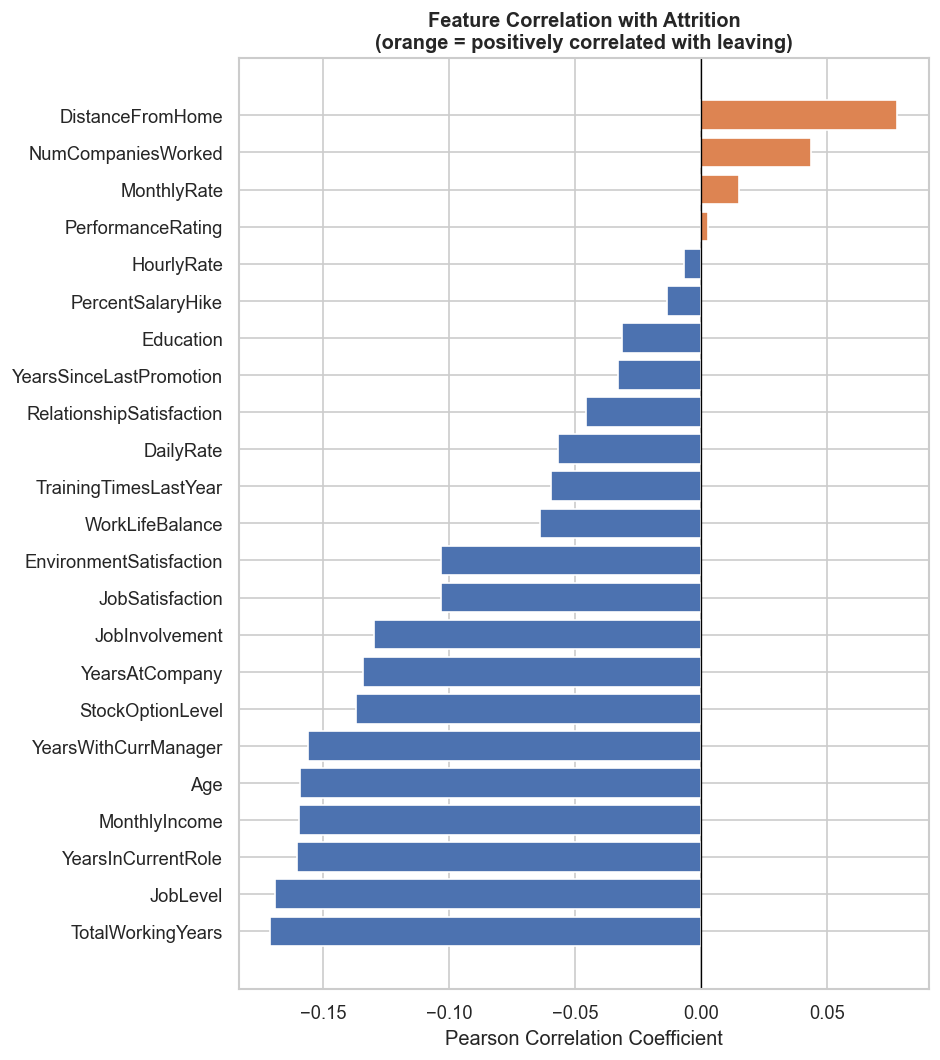

Top 5 features positively correlated with attrition:
HourlyRate           -0.007
PerformanceRating     0.003
MonthlyRate           0.015
NumCompaniesWorked    0.043
DistanceFromHome      0.078

Top 5 features negatively correlated with attrition:
TotalWorkingYears    -0.171
JobLevel             -0.169
YearsInCurrentRole   -0.161
MonthlyIncome        -0.160
Age                  -0.159


In [10]:
DROP_COLS = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber',
             'TenureBucket', 'AgeGroup']
df_corr = df.drop(columns=[c for c in DROP_COLS if c in df.columns]).copy()
df_corr['Attrition_bin'] = (df_corr['Attrition'] == 'Yes').astype(int)
df_corr = df_corr.drop(columns=['Attrition'])

corr = df_corr.corr(numeric_only=True)['Attrition_bin'].drop('Attrition_bin')
corr = corr.sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Attrition\n(orange = positively correlated with leaving)',
             fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig(PLOT_DIR / '05_correlation_target.png', bbox_inches='tight')
plt.show()

print('Top 5 features positively correlated with attrition:')
print(corr.tail(5).round(3).to_string())
print('\nTop 5 features negatively correlated with attrition:')
print(corr.head(5).round(3).to_string())

## 10. Fairness Audit: Protected Attributes

Per the proposal, disparate-impact audits are required on **Age**, **Gender**, and **MaritalStatus** before any deployment. These are protected attributes in most employment jurisdictions. We report group-level attrition rates in the raw data to flag pre-existing disparities.

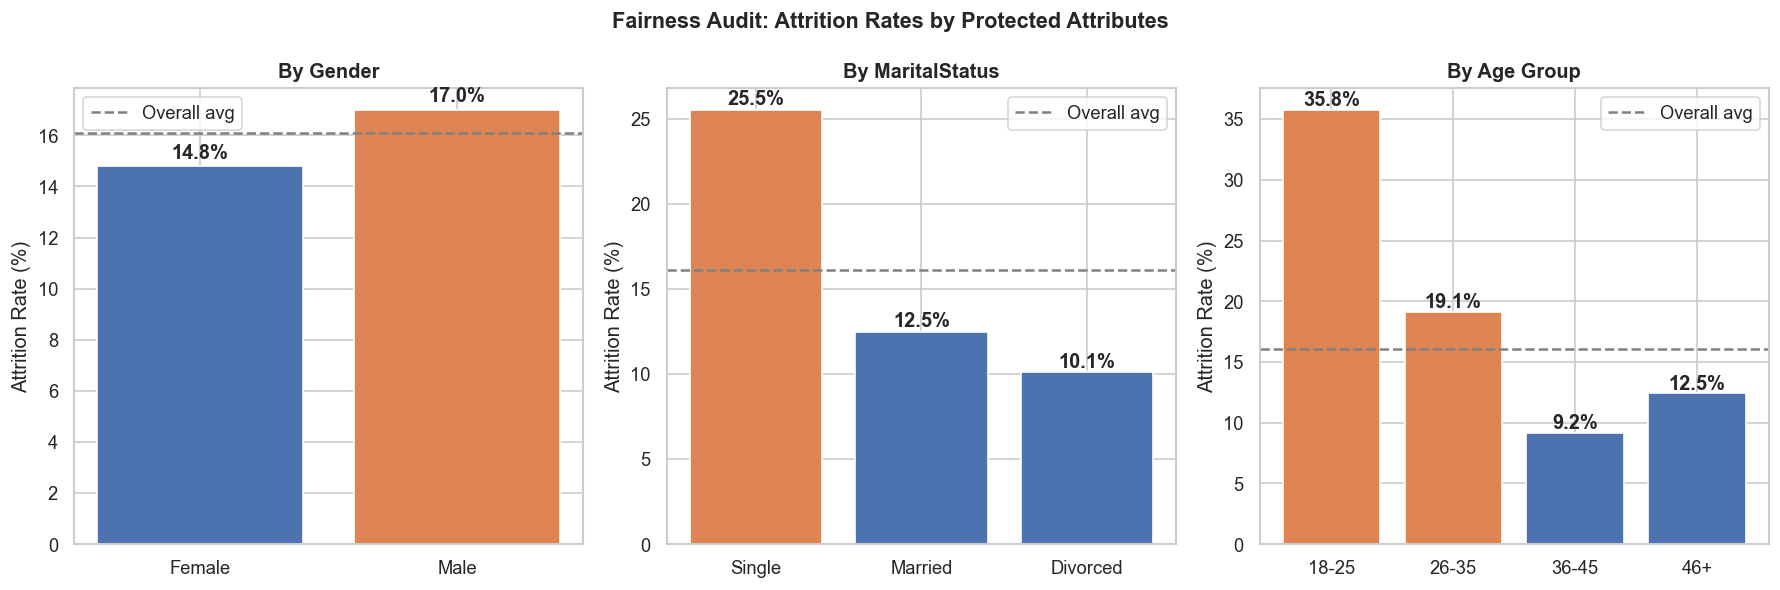

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Gender ---
gender_rate = df.groupby('Gender')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
axes[0].bar(gender_rate.index, gender_rate.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].axhline(y=16.1, color='gray', linestyle='--', label='Overall avg')
axes[0].set_title('By Gender', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].legend()
for i, (_, val) in enumerate(gender_rate.items()):
    axes[0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

# --- MaritalStatus ---
marital_rate = df.groupby('MaritalStatus')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)
colors_m = ['#DD8452' if v > 16.1 else '#4C72B0' for v in marital_rate.values]
axes[1].bar(marital_rate.index, marital_rate.values, color=colors_m, edgecolor='white')
axes[1].axhline(y=16.1, color='gray', linestyle='--', label='Overall avg')
axes[1].set_title('By MaritalStatus', fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].legend()
for i, (_, val) in enumerate(marital_rate.items()):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

# --- Age Group ---
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 25, 35, 45, 100],
                         labels=['18-25', '26-35', '36-45', '46+'])
age_rate = df.groupby('AgeGroup', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
colors_a = ['#DD8452' if v > 16.1 else '#4C72B0' for v in age_rate.values]
axes[2].bar(age_rate.index.astype(str), age_rate.values, color=colors_a, edgecolor='white')
axes[2].axhline(y=16.1, color='gray', linestyle='--', label='Overall avg')
axes[2].set_title('By Age Group', fontweight='bold')
axes[2].set_ylabel('Attrition Rate (%)')
axes[2].legend()
for i, (_, val) in enumerate(age_rate.items()):
    axes[2].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Fairness Audit: Attrition Rates by Protected Attributes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '06_fairness_audit.png', bbox_inches='tight')
plt.show()

### Key Attrition Insights

* **Age:** The youngest employees (18-25) have the highest turnover at **35.8%**, dropping significantly for older groups.
* **Marital Status:** Single employees leave at **25.5%**, more than double the rate of married or divorced staff.
* **Gender:** Attrition differences are minimal (Men: **17.0%**, Women: **14.8%**).

**Takeaway:** The company's primary retention challenge is young, single employees. 


In [12]:
print('=== FAIRNESS AUDIT — DATA-LEVEL SUMMARY ===')
print()
print('Gender (gap between groups):')
for group, rate in gender_rate.items():
    print(f'  {group:<10}: {rate:.1f}%')
print(f'  Disparity gap: {gender_rate.max() - gender_rate.min():.1f} pp')

print()
print('MaritalStatus:')
for group, rate in marital_rate.items():
    print(f'  {group:<10}: {rate:.1f}%')
print(f'  Disparity gap: {marital_rate.max() - marital_rate.min():.1f} pp')

print()
print('Age Group:')
for group, rate in age_rate.items():
    print(f'  {str(group):<10}: {rate:.1f}%')
print(f'  Disparity gap: {age_rate.max() - age_rate.min():.1f} pp')

print()
print('ACTION ITEMS for Stage 03:')
print('  - After training, compute group-level Precision, Recall, and FPR')
print('    for each protected attribute')
print('  - Ensure model does not amplify the Single/young-employee disparity')
print('  - Document findings before any hypothetical deployment')

=== FAIRNESS AUDIT — DATA-LEVEL SUMMARY ===

Gender (gap between groups):
  Female    : 14.8%
  Male      : 17.0%
  Disparity gap: 2.2 pp

MaritalStatus:
  Single    : 25.5%
  Married   : 12.5%
  Divorced  : 10.1%
  Disparity gap: 15.4 pp

Age Group:
  18-25     : 35.8%
  26-35     : 19.1%
  36-45     : 9.2%
  46+       : 12.5%
  Disparity gap: 26.6 pp

ACTION ITEMS for Stage 03:
  - After training, compute group-level Precision, Recall, and FPR
    for each protected attribute
  - Ensure model does not amplify the Single/young-employee disparity
  - Document findings before any hypothetical deployment


## 11. Key Findings Summary

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **16.1% attrition rate** — class imbalance | F1 as primary metric; class weights first, SMOTE as fallback |
| 2 | **Naïve baseline: 83.9% accuracy, F1=0.00** | Sets the floor; any useful model must beat F1=0.50 |
| 3 | **OverTime=Yes → 30.5% attrition** vs 10.4% | Strongest single predictor; binary encode |
| 4 | **New hires (0–2 yrs) leave at 3x the rate** of veterans | `TenureBucket` engineered feature justified |
| 5 | **Leavers earn $4,787 vs $6,833 (stayers)** | `MonthlyIncome` key feature; `WorkloadPayPressure` justified |
| 6 | **All 4 satisfaction scores inversely correlated** | `AverageSatisfaction` composite feature justified |
| 7 | **Promotion stagnation visible** in tenure data | `PromotionStagnationRatio` feature justified |
| 8 | **Single employees: 25.5% attrition** | Predictive but protected attribute — fairness monitoring required |
| 9 | **Age 18–25: highest attrition group** | Predictive but protected — fairness monitoring required |
| 10 | **4 useless columns confirmed** | Drop before any modelling |

---
**Next step:** `02-features/attrition_fe.ipynb` — preprocessing pipeline + 4 engineered features.

### Modeling Key Findings

* **Target Imbalance:** A 16.1% attrition rate means accuracy is misleading (baseline is 83.9%). The model must prioritize **F1-score** and use class weighting.
* **Top Predictors:** Overtime is the strongest single trigger (30.5% attrition). Low pay, low satisfaction, and being a new hire are also major factors.
* **Feature Engineering:** The data justifies creating 4 new features: `TenureBucket`, `WorkloadPayPressure`, `AverageSatisfaction`, and `PromotionStagnationRatio`.
* **Fairness Monitoring:** Age (18-25) and Single status are highly predictive but are protected attributes, requiring careful auditing.

**Next Step:** Drop the 4 useless columns and build the preprocessing pipeline. 